#### Preparing data

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import xgboost as xgb

In [8]:
df = pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(0)
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [10]:
print(df.shape)
display(df.head())
print(df.dtypes)
print(df.isna().sum())

(10000, 11)


,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,0.0,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,0.0,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
fuel_efficiency_mpg    0
dtype: int64


In [11]:
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
X_val = df_val.drop(columns=['fuel_efficiency_mpg'])
X_test = df_test.drop(columns=['fuel_efficiency_mpg'])

#### Question 1

In [13]:
dv = DictVectorizer(sparse=True)
X_train_dict = X_train.to_dict(orient='records')
X_train_encoded = dv.fit_transform(X_train_dict)

tree = DecisionTreeRegressor(max_depth=1)
tree.fit(X_train_encoded, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes m

In [14]:
split_index = tree.tree_.feature[0]
split_name = dv.get_feature_names_out()[split_index]
split_name

'model_year'

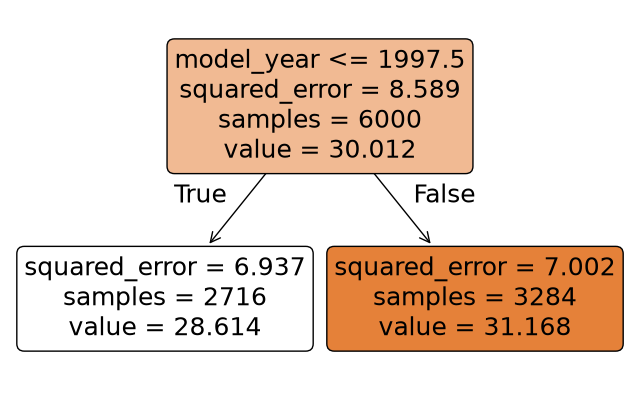

In [18]:
plt.figure(figsize=(8, 5))
plot_tree(
    tree,
    feature_names=dv.get_feature_names_out(),
    filled=True,
    rounded=True,
)
plt.show()

In [20]:
X_val_encoded = dv.transform(X_val.to_dict(orient='records'))
y_val_pred = tree.predict(X_val_encoded)

In [26]:
np.sqrt(mean_squared_error(y_val, y_val_pred))

np.float64(2.672633736937051)

#### Question 2

In [29]:
rf = RandomForestRegressor(
    n_estimators=10,
    random_state=1,
    n_jobs=-1,
)
rf.fit(X_train_encoded, y_train)
y_val_pred = rf.predict(X_val_encoded)
np.sqrt(mean_squared_error(y_val, y_val_pred))

np.float64(1.8332197358745623)

#### Question 3

In [30]:
results = []

for n in [10, 50, 100, 150]:
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=1,
        n_jobs=-1,
    )
    rf.fit(X_train_encoded, y_train)

    y_val_pred = rf.predict(X_val_encoded)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results.append({"n_estimators": n, "rmse": rmse})

pd.DataFrame(results).sort_values("rmse")

,n_estimators,rmse
3,150,1.769198
2,100,1.769786
1,50,1.773988
0,10,1.833220


#### Question 4

In [33]:
depths = [10, 15, 20, 25]
n_estimators_values = [10, 50, 100, 150]
results = []

for depth in depths:
    for n in n_estimators_values:
        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=1,
            n_jobs=-1,
        )
        rf.fit(X_train_encoded, y_train)

        y_val_pred = rf.predict(X_val_encoded)
        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

        results.append({
            "max_depth": depth,
            "n_estimators": n,
            "rmse": rmse,
        })

results_df = pd.DataFrame(results)

display(results_df)
display(
    results_df.groupby(["max_depth"])["rmse"]
    .mean()
    .sort_values()
)

,max_depth,n_estimators,rmse
0,10,10,1.782348
1,10,50,1.747520
2,10,100,1.743986
3,10,150,1.743716
4,15,10,1.831390
5,15,50,1.770883
6,15,100,1.767872
7,15,150,1.766752
8,20,10,1.837314
9,20,50,1.772377


max_depth
10    1.754392
15    1.784224
25    1.786305
20    1.786771
Name: rmse, dtype: float64

In [38]:
results_df.iloc[results_df.groupby("max_depth")["rmse"].idxmin()]

,max_depth,n_estimators,rmse
3,10,150,1.743716
7,15,150,1.766752
11,20,150,1.768476
15,25,150,1.767927


#### Question 5

In [41]:
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1,
)
rf.fit(X_train_encoded, y_train)

importance_df = pd.DataFrame({
    "feature": dv.get_feature_names_out(),
    "importance": rf.feature_importances_,
})

In [42]:
importance_df

,feature,importance
0,acceleration,0.054998
1,drivetrain=All-wheel drive,0.007951
2,drivetrain=Front-wheel drive,0.020062
3,drivetrain=Rear-wheel drive,0.005638
4,engine_displacement,0.061281
5,fuel_type=Diesel,0.016571
6,fuel_type=Gasoline,0.160712
7,fuel_type=Hybrid,0.016272
8,horsepower,0.078271
9,model_year,0.296107


In [43]:
candidates = [
    "vehicle_weight",
    "horsepower",
    "acceleration",
    "engine_displacement",
]

importance_df[importance_df["feature"].isin(candidates)].sort_values(
    "importance",
    ascending=False,
)

,feature,importance
15,vehicle_weight,0.203313
8,horsepower,0.078271
4,engine_displacement,0.061281
0,acceleration,0.054998


#### Question 6

In [48]:
feature_names = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train_encoded, label=y_train, feature_names=feature_names)
dval = xgb.DMatrix(X_val_encoded, label=y_val, feature_names=feature_names)

watchlist = [(dtrain, 'train'), (dval, 'eval')]

In [51]:
results = []
etas = [0.3, 0.1]

for eta in etas:
    evals_result = {}

    xgb_params = {
        "eta": eta,
        "max_depth": 6,
        "min_child_weight": 1,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "nthread": 8,  # wartość podana w treści homeworku
        "seed": 1,
        "verbosity": 1,
    }

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=100,
        evals=watchlist,
        evals_result=evals_result,
        verbose_eval=False,
    )

    results.append({
        "eta": eta,
        "validation_rmse": evals_result["eval"]["rmse"][-1],
    })

pd.DataFrame(results)
    


,eta,validation_rmse
0,0.3,1.826458
1,0.1,1.724810


In [52]:
print(results)

[{'eta': 0.3, 'validation_rmse': 1.8264579949460302}, {'eta': 0.1, 'validation_rmse': 1.7248100768778967}]


In [57]:
history_rows = []

for round_num, (train_rmse, val_rmse) in enumerate(
    zip(evals_result["train"]["rmse"], evals_result["eval"]["rmse"]),
    start=1,
):
    history_rows.append({
        "eta": eta,
        "round": round_num,
        "train_rmse": train_rmse,
        "validation_rmse": val_rmse,
    })

history_df = pd.DataFrame(history_rows)
display(history_df)

,eta,round,train_rmse,validation_rmse
0,0.1,1,2.747386,2.786354
1,0.1,2,2.585269,2.631623
2,0.1,3,2.445401,2.500364
3,0.1,4,2.321873,2.385678
4,0.1,5,2.214446,2.287646
...,...,...,...,...
95,0.1,96,1.322918,1.723239
96,0.1,97,1.322619,1.723407
97,0.1,98,1.319195,1.723542
98,0.1,99,1.314547,1.724135
